4장 컴퓨터 비전

In [ ]:
# 예제 4.1 이미지 분류 CNN 모델(CIFAR-10)

#셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)   # 테스트 데이터 shape 확인

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


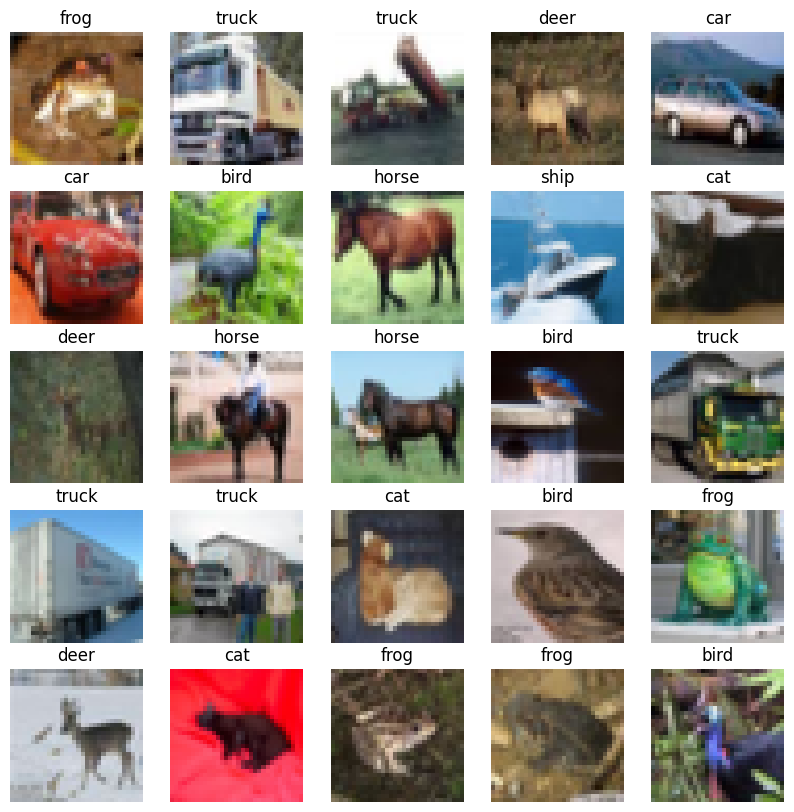

In [ ]:
# 학습 데이터 시각화
class_names = ["plane", "car", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i].item()])
    plt.axis("off")

plt.show()

In [ ]:
# 데이터 정규화
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
# 특징 추출 신경망
inputs = Input(shape=(32, 32, 3))
x = Conv2D(32, kernel_size=3, padding="same", activation="relu")(inputs)
x = Conv2D(32, kernel_size=3, padding="same", activation="relu")(x)
x = MaxPooling2D(pool_size=2)(x)

x = Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
x = Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
x = MaxPooling2D(pool_size=2)(x)

x = Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
x = MaxPooling2D(pool_size=2)(x)

# 분류 신경망
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation="softmax")(x)

# 모델 생성
model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
# 모델 학습
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3)

history = model.fit(x_train, y_train, epochs=50,
                    validation_split=0.2, verbose=0,
                    callbacks=early_stopping)

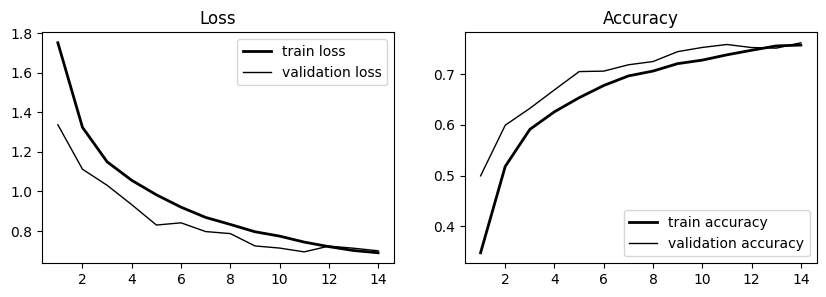

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], label="train loss",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_loss"]) + 1),
         history.history["val_loss"], label="validation loss",
         color="black", linewidth=1)
plt.title("Loss")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history.history["accuracy"]) + 1),
         history.history["accuracy"], label="train accuracy",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_accuracy"]) + 1),
         history.history["val_accuracy"], label="validation accuracy",
         color="black", linewidth=1)
plt.title("Accuracy")
plt.legend(loc="best")

plt.show()

In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7529 - loss: 0.7242


[0.7299676537513733, 0.7501999735832214]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


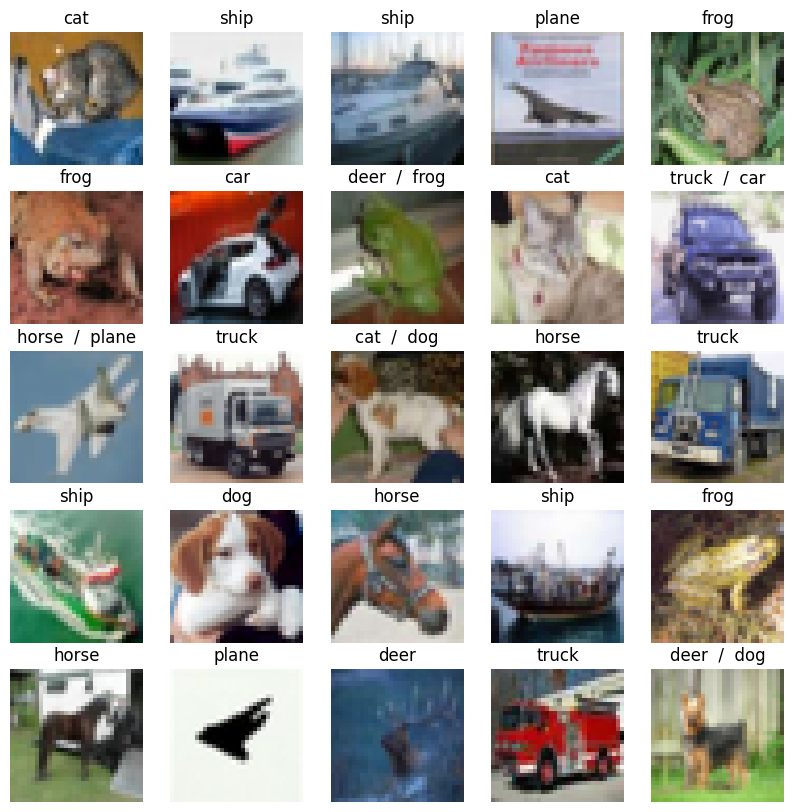

In [ ]:
# 모델 예측 결과 시각화
x = x_test[:25]
y_pred = np.argmax(model.predict(x), axis=1)

plt.figure(figsize=(10 ,10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_test[i])
    if y_pred[i] != y_test[i]:
        plt.title(class_names[y_pred[i].item()] + '  /  '
                 + class_names[y_test[i].item()])
    else:
        plt.title(class_names[y_pred[i].item()])
    plt.axis("off")

plt.show()

예제 4.2

https://www.kaggle.com/datasets/birajsth/cats-and-dogs-filtered?utm_source=chatgpt.com

In [ ]:
# 예제 4.2 VGG16 전이 학습(Cats_and_Dogs)

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# 학습 데이터/검증 데이터 경로 지정
train_dir = "/content/drive/MyDrive/Datasets/cats_and_dogs_filtered/train"
test_dir = "/content/drive/MyDrive/Datasets/cats_and_dogs_filtered/test"

In [ ]:
# 데이터셋 준비
train_ds = image_dataset_from_directory(train_dir, shuffle=True,
                                        batch_size=32,
                                        image_size=(160, 160))
test_ds = image_dataset_from_directory(test_dir, shuffle=True,
                                        batch_size=32,
                                        image_size=(160, 160))

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


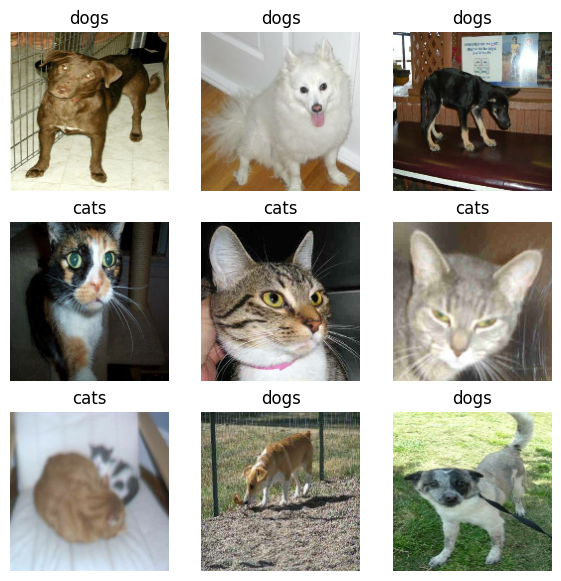

In [ ]:
# 학습 데이터 시각화
class_name = train_ds.class_names   # 클래스명(cats, dogs)

for image, label in train_ds.take(1):   # 레이블(0, 1)
    plt.figure(figsize=(7, 7))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image[i] / 255)
        plt.title(class_name[label[i]])
        plt.axis("off")
    plt.show()

In [ ]:
# 검증/테스트 데이터 분할
test_batch = len(test_ds)
valid_ds = test_ds.skip(test_batch // 2)   # 분할 비율 0.5
test_ds = test_ds.take(test_batch // 2)

In [ ]:
# VGG16 베이스 모델 생성
base_model = VGG16(include_top=False,   # 분류 신경망 포함하지 않음
                   weights="imagenet",   # ImageNet으로 학습한 가중치
                   input_shape=(160, 160, 3))

base_model.trainable = False   # 베이스 모델 동결

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 모델 생성
inputs = Input(shape=(160, 160, 3))
x = preprocess_input(inputs)   # VGG16 전처리
x = base_model(x)    # VGG16 베이스 모델
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)   # 은닉층 뉴런 128개
x = Dropout(0.5)(x)   # 드롭아웃 확률 0.5
outputs = Dense(1, activation="sigmoid")(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
# 모델 학습
history = model.fit(train_ds, epochs=5, validation_data=valid_ds)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 774s 12s/step - accuracy: 0.8136 - loss: 1.6716 - val_accuracy: 0.9713 - val_loss: 0.0907
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.9563 - loss: 0.1791 - val_accuracy: 0.9754 - val_loss: 0.0668
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.9668 - loss: 0.1115 - val_accuracy: 0.9631 - val_loss: 0.0773
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.9703 - loss: 0.0664 - val_accuracy: 0.9734 - val_loss: 0.0680
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.9831 - loss: 0.0474 - val_accuracy: 0.9795 - val_loss: 0.0562


In [ ]:
# 모델 평가
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9744 - loss: 0.0761


[0.07546869665384293, 0.9733606576919556]

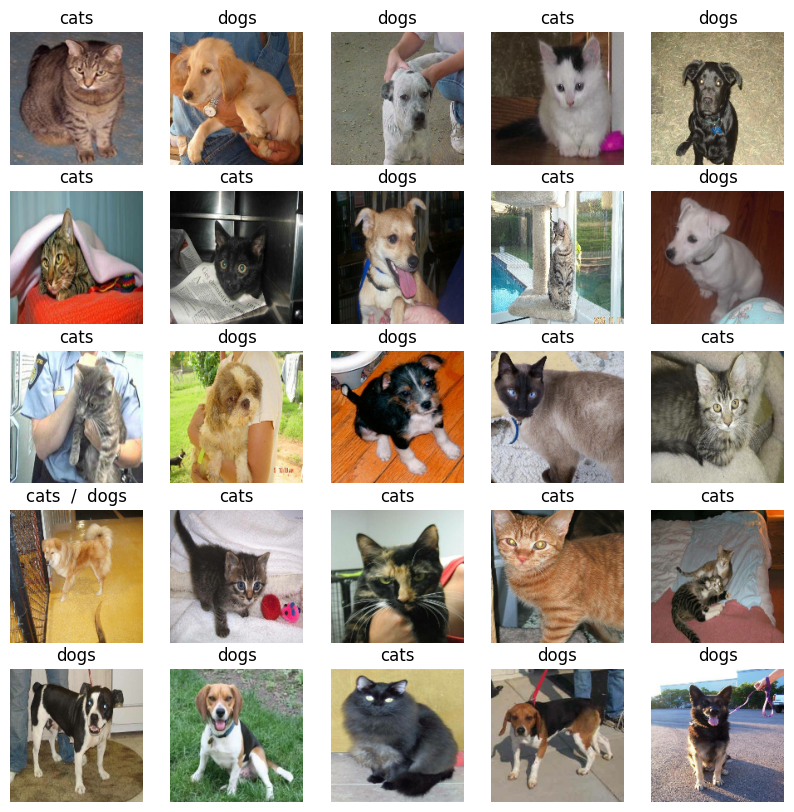

In [ ]:
# 모델 예측 결과 시각화
image, label = next(iter(test_ds))        # 이터레이터 사용하여 배치 가져옴
prediction = model.predict_on_batch(image).reshape(-1)   # 배치 단위로 예측
predict = (prediction >= 0.5).astype(int)   # 임계치 0.5

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(image[i] / 255)

    if predict[i] != label[i]:
        plt.title(class_name[predict[i]] + '  /  '
                  + class_name[label[i]])
    else:
        plt.title(class_name[predict[i]])

    plt.axis("off")

plt.show()